In [1]:
# from google.colab import drive
# drive.mount("/content/gdrive", force_remount=True)

In [2]:
# import sys
import os
# sys.path.append('/content/gdrive/MyDrive/???/')
# os.chdir('/content/gdrive/MyDrive/???/')
os.chdir('./stat_csv')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# Load your time series data
df = pd.read_csv('bike_day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
df.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

#### String Time Format Code List: https://strftime.org/

In [6]:
df['dteday'] = pd.to_datetime(df['dteday'], format='%Y-%m-%d')  # Match format according to the data pattern
df = df.set_index('dteday')
df.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
dteday,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [7]:
df.columns

Index(['instant', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt'],
      dtype='object')

### SARIMA Model

In [8]:
train = df.loc[df.index <= '2012-11-01']
test = df.loc[df.index > '2012-11-01']
forecast_steps = len(test)

TARGET = 'cnt'
y_train = train[TARGET]
y_test = test[TARGET]

In [9]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set frequeuncy of time index
train.index = pd.DatetimeIndex(train.index, freq='D')
train.index.inferred_freq

log_train = np.log(train[TARGET])
# Define the model
model = SARIMAX(log_train,
                order=(6, 1, 0),
                seasonal_order=(2, 0, 0, 7),
                )

# Fit the model
model_fit = model.fit()

# Make predictions
log_forecast = model_fit.forecast(steps=forecast_steps)
forecast = np.exp(log_forecast)

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test[TARGET], forecast))
mae = mean_absolute_error(test[TARGET], forecast)
print("RMSE:", rmse, ", MAE :", mae)

RMSE: 1954.7785952863499 , MAE : 1777.4599441679907


/tmp/ipykernel_101976/1282433397.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['arima_prediction'] = forecast


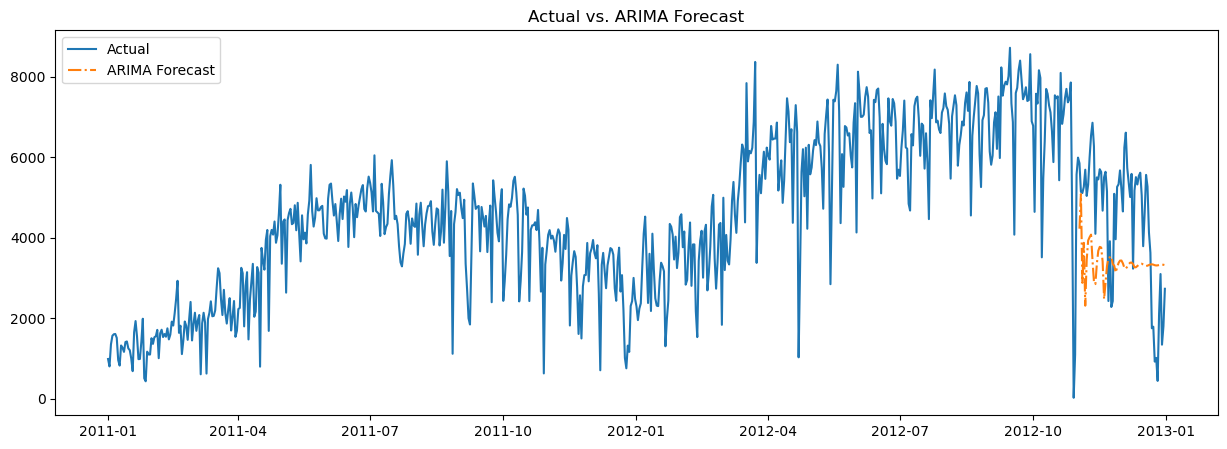

In [10]:
result = df.copy()
test['arima_prediction'] = forecast
result = result.merge(test['arima_prediction'], how='left', left_index=True, right_index=True)

plt.figure(figsize=(15,5))
plt.plot(result[TARGET])
plt.plot(test['arima_prediction'], '-.')
plt.legend(['Actual', 'ARIMA Forecast'])
plt.title('Actual vs. ARIMA Forecast')
plt.show()

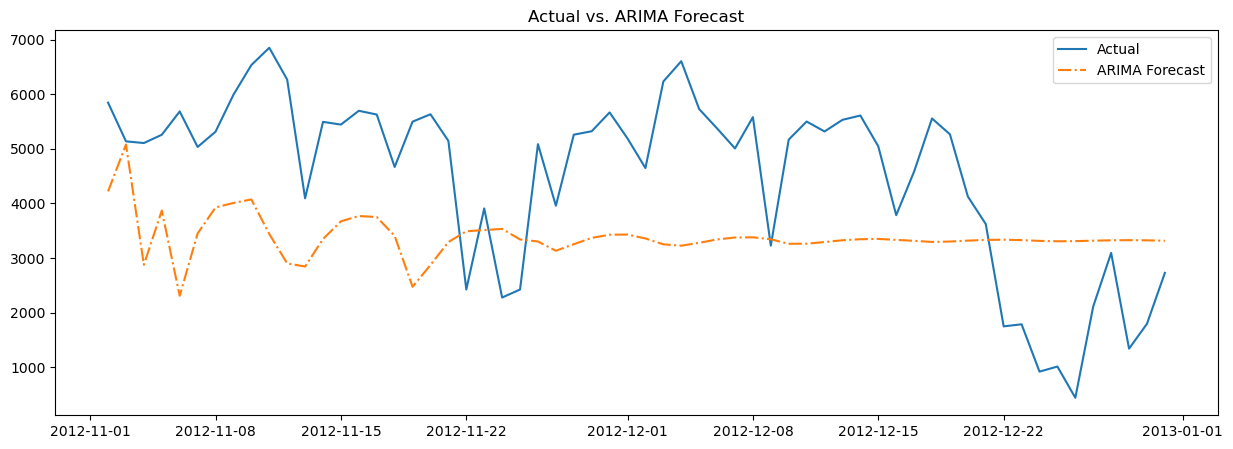

In [11]:
plt.figure(figsize=(15,5))
plt.plot(test[TARGET])
plt.plot(test['arima_prediction'], '-.')
plt.legend(['Actual', 'ARIMA Forecast'])
plt.title('Actual vs. ARIMA Forecast')
plt.show()

### Regression with Lags

In [12]:
value_var = 'cnt'

In [13]:
def create_lags(data, lags=12):
    df_lag = pd.DataFrame(index=data.index)

    for i in range(1, lags+1):
        df_lag[f'lag_{i}'] = data.shift(i)

    df_lag['y'] = data
    return df_lag.dropna()

data = create_lags(df[value_var], lags=12)
data.head()

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,y
dteday,,,,,,,,,,,,,
2011-01-13,1162.0,1263.0,1321.0,822.0,959.0,1510.0,1606.0,1600.0,1562.0,1349.0,801.0,985.0,1406
2011-01-14,1406.0,1162.0,1263.0,1321.0,822.0,959.0,1510.0,1606.0,1600.0,1562.0,1349.0,801.0,1421
2011-01-15,1421.0,1406.0,1162.0,1263.0,1321.0,822.0,959.0,1510.0,1606.0,1600.0,1562.0,1349.0,1248
2011-01-16,1248.0,1421.0,1406.0,1162.0,1263.0,1321.0,822.0,959.0,1510.0,1606.0,1600.0,1562.0,1204
2011-01-17,1204.0,1248.0,1421.0,1406.0,1162.0,1263.0,1321.0,822.0,959.0,1510.0,1606.0,1600.0,1000


In [14]:
split = int(len(data)*0.7)

train = data.iloc[:split]
test  = data.iloc[split:]

X_train, y_train = train.drop(columns='y'), train['y']
X_test,  y_test  = test.drop(columns='y'),  test['y']

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
reg_predictions = model.predict(X_test_scaled)


from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, reg_predictions)
rmse = np.sqrt(mean_squared_error(y_test, reg_predictions))

print("RMSE:", rmse, "MAE:", mae)

RMSE: 1130.5659783215015 MAE: 794.5868610283194


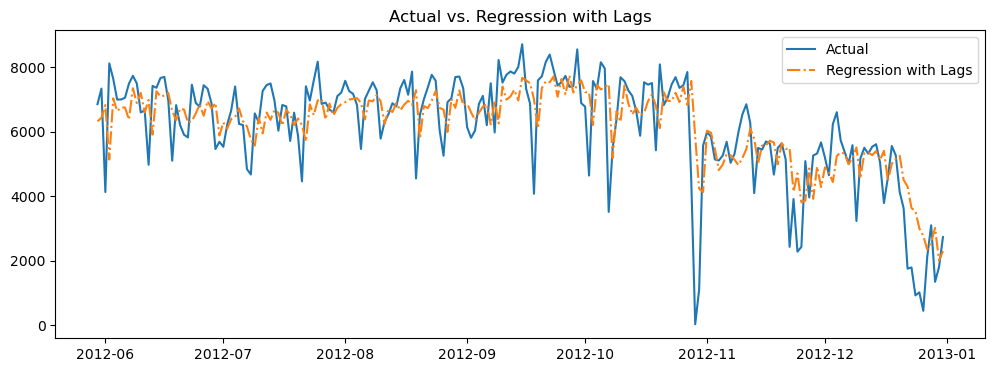

In [18]:
plt.figure(figsize=(12,4))
plt.plot(y_test, label="Actual")
plt.plot(y_test.index, reg_predictions, '-.', label="Regression with Lags")
plt.legend(['Actual', 'Regression with Lags'])
plt.title('Actual vs. Regression with Lags')
plt.show()

### RNN with Lags

In [19]:
value_var = 'cnt'

In [20]:
from sklearn.preprocessing import StandardScaler

data = df[value_var].values.astype('float32')
data = data.reshape(-1,1)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data).flatten()

In [21]:
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window=14)

In [22]:
X = X.reshape((X.shape[0], X.shape[1], 1))
split = int(len(X)*0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

window = 14
rnn = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

rnn.compile(optimizer='adam', loss='mse')
rnn.fit(X_train, y_train, epochs=100, verbose=1)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5786   
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3109 
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2711 
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2472 
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2311 
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2219 
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2143 
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2073 
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2031 
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1997 
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1958 
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1930 
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1916 
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1891 
Epoch 15/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

In [26]:
rnn_predictions = rnn.predict(X_test)

y_test_inv  = scaler.inverse_transform(y_test.reshape(-1,1))
rnn_predictions_inv  = scaler.inverse_transform(rnn_predictions)

# Evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_inv, rnn_predictions_inv))
mae = mean_absolute_error(y_test_inv, rnn_predictions_inv)
print("RMSE:", rmse, ", MAE :", mae)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
RMSE: 1270.6370941382122 , MAE : 907.2449951171875


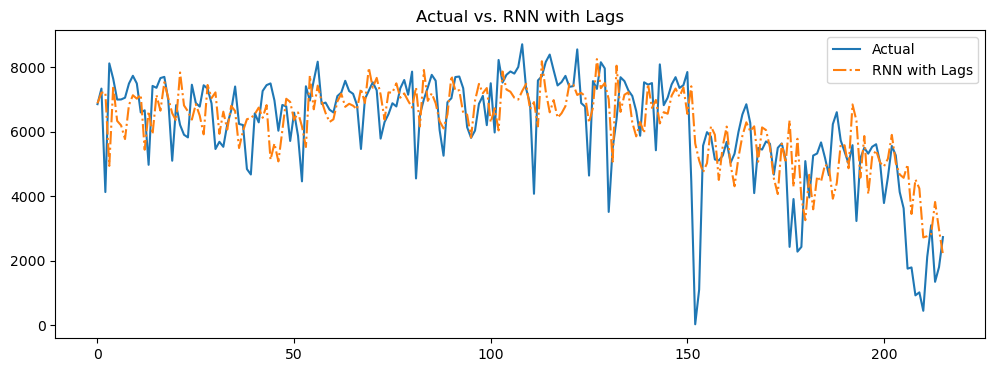

In [28]:
plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label="Actual")
plt.plot(rnn_predictions_inv, '-.', label="RNN with Lags")
plt.legend(['Actual', 'RNN with Lags'])
plt.title('Actual vs. RNN with Lags')
plt.show()

### LSTM with Lags

In [29]:
from tensorflow.keras.layers import LSTM

lstm = Sequential([
    LSTM(32, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')

lstm.fit(X_train, y_train, epochs=100, verbose=1)

Epoch 1/100


/nix/store/lvk9lnrkgsp34niv9916v1m2is60s9si-devenv-profile/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3847
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2468 
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2208 
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2152 
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2134 
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2121 
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2111 
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2106 
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2088 
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2085 
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2084 
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2071 
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2058 
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2053 
Epoch 15/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2050 
Ep

In [30]:
lstm_predictions = lstm.predict(X_test)

y_test_inv  = scaler.inverse_transform(y_test.reshape(-1,1))
lstm_predictions_inv  = scaler.inverse_transform(lstm_predictions)

# Evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_inv, lstm_predictions_inv))
mae = mean_absolute_error(y_test_inv, lstm_predictions_inv)
print("RMSE:", rmse, ", MAE :", mae)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
RMSE: 1339.100677693802 , MAE : 1097.3443603515625


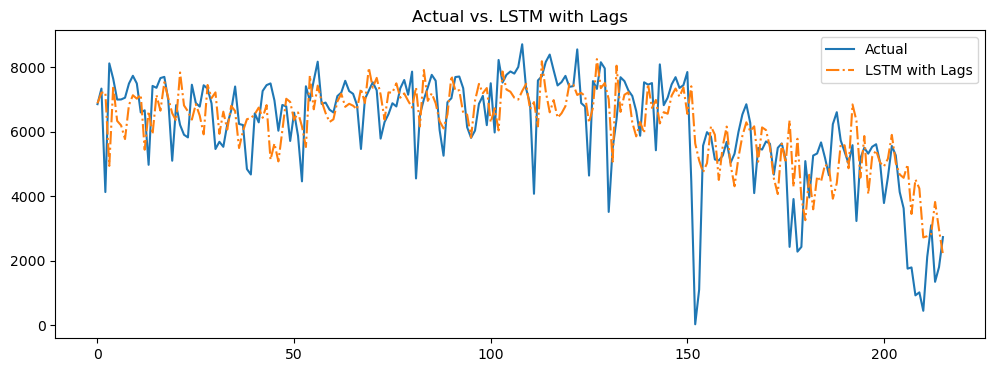

In [31]:
plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label="Actual")
plt.plot(rnn_predictions_inv, '-.', label="LSTM with Lags")
plt.legend(['Actual', 'LSTM with Lags'])
plt.title('Actual vs. LSTM with Lags')
plt.show()

### RNN with features

In [32]:
train = df.loc[df.index <= '2012-11-01']
test = df.loc[df.index > '2012-11-01']
forecast_steps = len(test)

FEATURES = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
            'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
TARGET = 'cnt'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


# Prepare your time series data (train_x, train_y)
train_x = np.array(X_train)  # input sequences
train_y = np.array(y_train)  # target values

# Reshape the data for RNN
train_x = train_x.reshape((train_x.shape[0], train_x.shape[1], 1))

# Build the RNN model
model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(train_x.shape[1], 1)))
model.add(Dense(1))

# Compile and fit the model
model.compile(optimizer='adam', loss='mse')
model.fit(train_x, train_y, epochs=20, verbose=1)

Epoch 1/20


/nix/store/lvk9lnrkgsp34niv9916v1m2is60s9si-devenv-profile/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 24134766.0000   
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23361004.0000 
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8768371.0000  
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4271033.5000 
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3687443.7500 
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3613211.5000 
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3495977.5000 
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3411026.7500 
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3468990.7500 
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3419572.5000 
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3399455.2500 
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3352388.0000 
Epoch 13/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3356646.0000 
Epoch 14/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3371980

In [34]:
# Predict values
test_x = np.array(X_test)  # input sequences
test_y = np.array(y_test)  # target values

predictions = model.predict(test_x)

# Evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, predictions))
mae = mean_absolute_error(test_y, predictions)
print("RMSE:", rmse, ", MAE :", mae)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/stepWARNING:tensorflow:6 out of the last 16 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7fb10c1b4e00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
RMSE: 1911.098963947184 , MAE : 1607.6270751953125


/tmp/ipykernel_101976/346553176.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['rnn_prediction'] = predictions


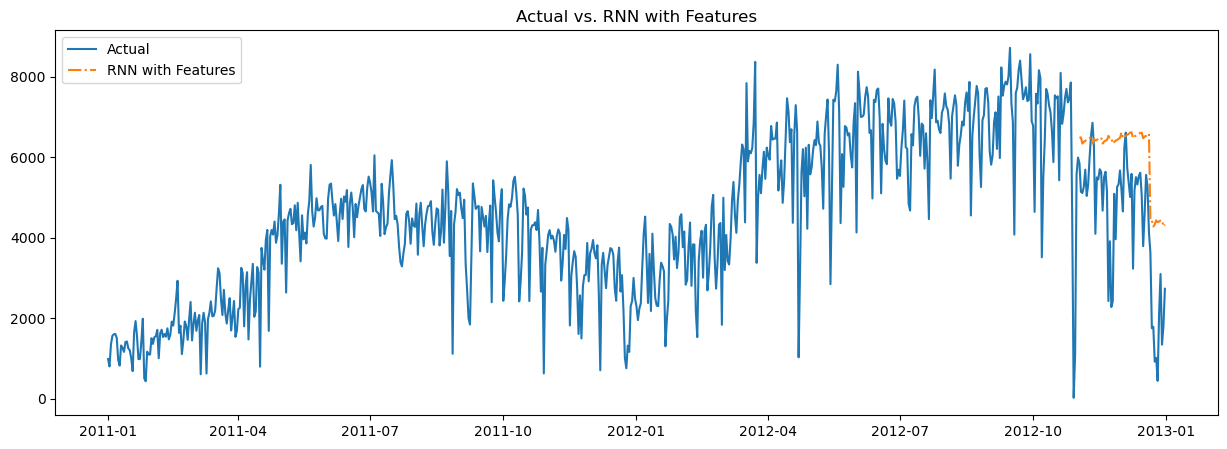

In [35]:
result = df.copy()
test['rnn_prediction'] = predictions
result = result.merge(test['rnn_prediction'], how='left', left_index=True, right_index=True)

plt.figure(figsize=(15,5))
plt.plot(result[[TARGET]])
plt.plot(test['rnn_prediction'], '-.')
plt.legend(['Actual', 'RNN with Features'])
plt.title('Actual vs. RNN with Features')
plt.show()

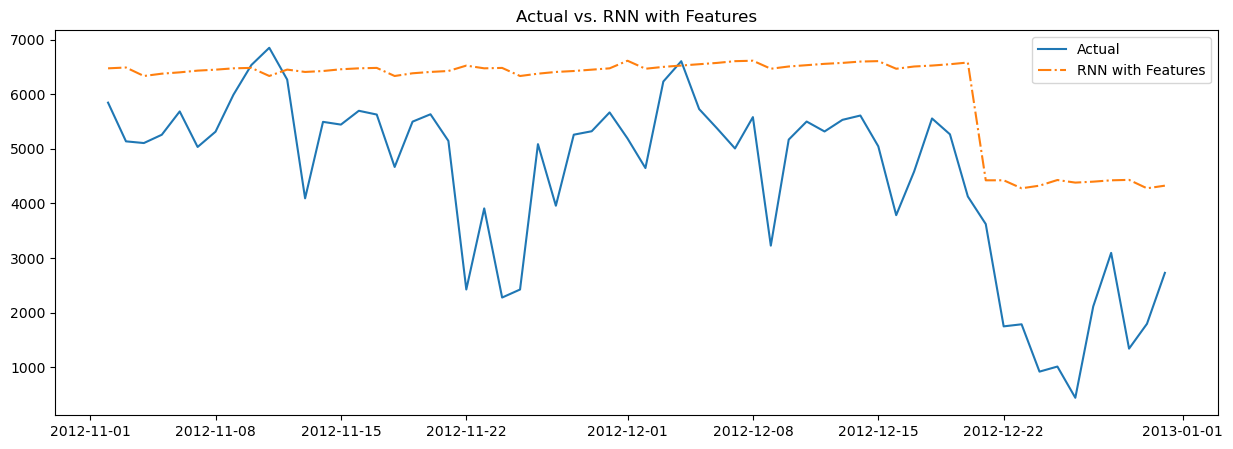

In [36]:
plt.figure(figsize=(15,5))
plt.plot(test[TARGET])
plt.plot(test['rnn_prediction'], '-.', label='RNN with Features')
plt.legend(['Actual', 'RNN with Features'])
plt.title('Actual vs. RNN with Features')
plt.show()

### LSTM with features

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Reshape for LSTM
train_x = train_x.reshape((train_x.shape[0], train_x.shape[1], 1))

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(train_x.shape[1], 1)))
model.add(Dense(1))

# Compile and fit the model
model.compile(optimizer='adam', loss='mse')
model.fit(train_x, train_y, epochs=20, verbose=1)

Epoch 1/20


/nix/store/lvk9lnrkgsp34niv9916v1m2is60s9si-devenv-profile/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 24143438.0000
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23983950.0000 
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14454018.0000 
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6558736.0000 
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5286012.0000 
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4594336.0000 
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4034626.7500 
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3702540.2500 
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3607059.7500 
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3139215.5000 
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2955097.2500 
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2762805.7500 
Epoch 13/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2657345.0000 
Epoch 14/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2561232.50

In [38]:
# Predict values
test_x = np.array(X_test)  # input sequences
test_y = np.array(y_test)  # target values

predictions = model.predict(test_x)

# Evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, predictions))
mae = mean_absolute_error(test_y, predictions)
print("RMSE:", rmse, ", MAE :", mae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
RMSE: 1274.5217240204265 , MAE : 860.5888671875


/tmp/ipykernel_101976/3405858396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['lstm_prediction'] = predictions


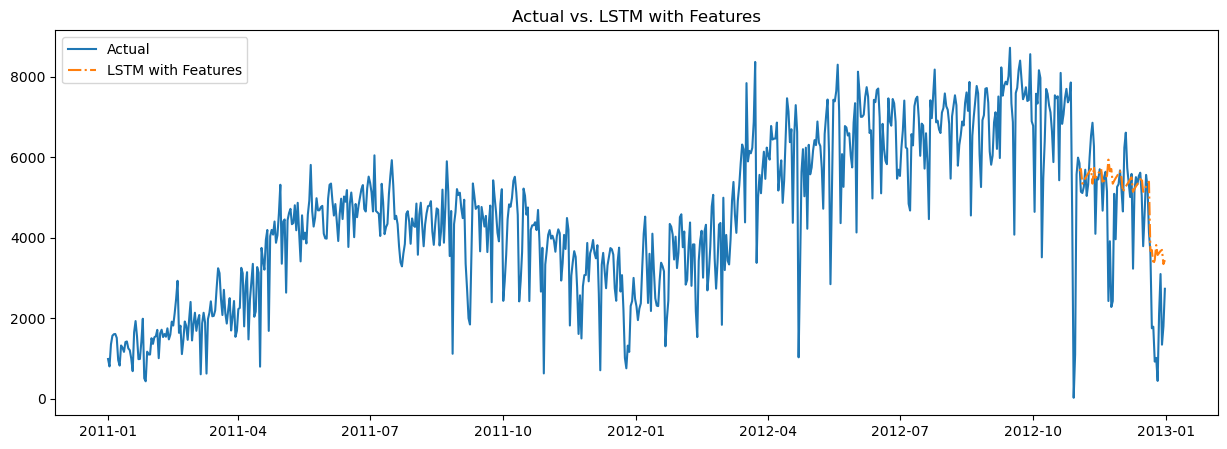

In [39]:
result = df.copy()
test['lstm_prediction'] = predictions
result = result.merge(test['lstm_prediction'], how='left', left_index=True, right_index=True)

plt.figure(figsize=(15,5))
plt.plot(result[[TARGET]])
plt.plot(test['lstm_prediction'], '-.')
plt.legend(['Actual', 'LSTM with Features'])
plt.title('Actual vs. LSTM with Features')
plt.show()

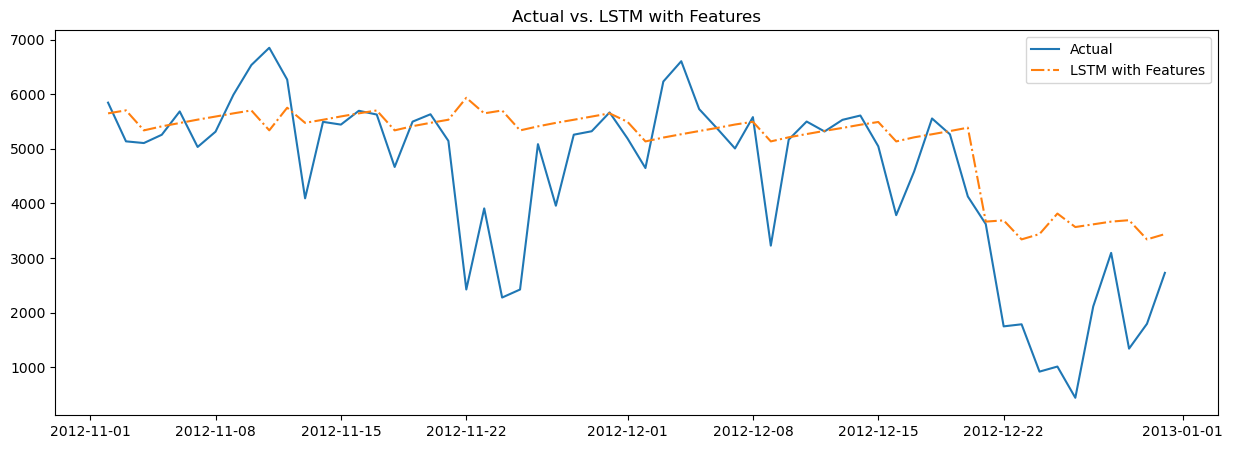

In [40]:
plt.figure(figsize=(15,5))
plt.plot(test[TARGET])
plt.plot(test['lstm_prediction'], '-.')
plt.legend(['Actual', 'LSTM with Features'])
plt.title('Actual vs. LSTM with Features')
plt.show()